In [1]:
import tensorflow as tf

# Konfigurasi untuk menggunakan GPU Lokal
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Mengaktifkan memory growth agar TensorFlow tidak memakan seluruh VRAM secara langsung
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Ditemukan {len(gpus)} GPU(s) lokal. Pelatihan akan menggunakan GPU.")
    except RuntimeError as e:
        print(e)
else:
    print("PERINGATAN: GPU tidak ditemukan! Pastikan CUDA dan cuDNN sudah terinstal. Pelatihan akan berjalan di CPU.")


I0000 00:00:1778658021.048077   10976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778658021.110139   10976 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778658023.052476   10976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Ditemukan 1 GPU(s) lokal. Pelatihan akan menggunakan GPU.


In [2]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf

IMG_SIZE = 96
BATCH_SIZE = 64
NUM_CLASSES = 7

# 1. Pipeline Training dengan tf.data (Lebih efisien & ramah RAM)
train_ds = tf.keras.utils.image_dataset_from_directory(
    'dataset_rafdb/train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

# 2. Pipeline Validasi
val_ds = tf.keras.utils.image_dataset_from_directory(
    'dataset_rafdb/test',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# 3. Optimasi CPU-to-GPU Handoff
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


Found 12271 files belonging to 7 classes.


I0000 00:00:1778658026.259597   10976 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 3068 files belonging to 7 classes.


In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomTranslation, RandomZoom, Rescaling
from tensorflow.keras.models import Model, Sequential
import tensorflow as tf

# 0. Augmentasi Data di dalam Model (Dieksekusi oleh GPU)
data_augmentation = Sequential([
    Rescaling(1./255),
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomTranslation(height_factor=0.1, width_factor=0.1),
    RandomZoom(0.1)
], name="data_augmentation")

# 1. Load Pre-trained Base Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

# 2. Bangun Custom Classification Head dengan Augmentasi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# 3. Satukan menjadi model utuh
model = Model(inputs=inputs, outputs=predictions)


In [4]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint('samaya_rafdb_mobilenetv2_best.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
]

EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50


I0000 00:00:1778658034.960219   11157 cuda_dnn.cc:461] Loaded cuDNN version 92200


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3113 - loss: 2.2916
Epoch 1: val_accuracy improved from None to 0.44752, saving model to samaya_rafdb_mobilenetv2_best.keras

Epoch 1: finished saving model to samaya_rafdb_mobilenetv2_best.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 35s 150ms/step - accuracy: 0.3613 - loss: 1.9652 - val_accuracy: 0.4475 - val_loss: 1.4513 - learning_rate: 0.0010
Epoch 2/50
191/192 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4244 - loss: 1.6220
Epoch 2: val_accuracy improved from 0.44752 to 0.47066, saving model to samaya_rafdb_mobilenetv2_best.keras

Epoch 2: finished saving model to samaya_rafdb_mobilenetv2_best.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.4375 - loss: 1.5687 - val_accuracy: 0.4707 - val_loss: 1.3920 - learning_rate: 0.0010
Epoch 3/50
191/192 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4574 - loss: 1.4890
Epoch 3: val_accuracy improved from 0.47066 to 0.47555, saving model to samaya_rafdb_mobilenetv2_best.keras

Sedang melakukan inferensi pada data validasi...
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       0.48      0.48      0.48       329
           2       0.80      0.11      0.19        74
           3       0.25      0.01      0.01       160
           4       0.63      0.68      0.65      1185
           5       0.38      0.52      0.44       478
           6       0.55      0.26      0.35       162
           7       0.47      0.50      0.49       680

    accuracy                           0.52      3068
   macro avg       0.51      0.36      0.37      3068
weighted avg       0.52      0.52      0.50      3068



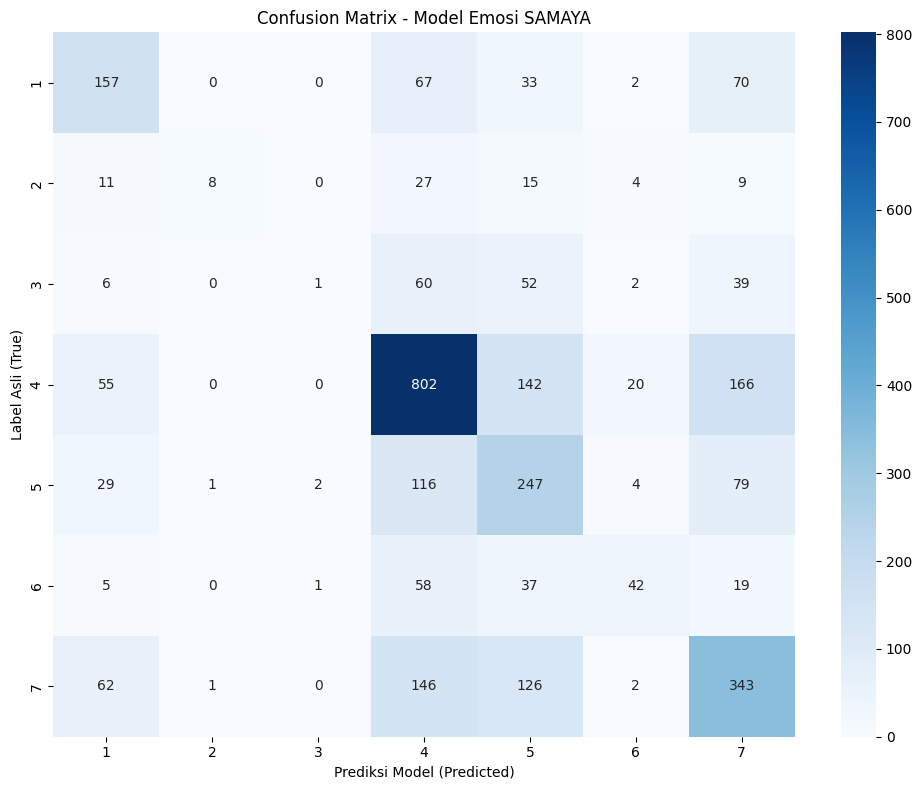

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

model = load_model('samaya_rafdb_mobilenetv2_best.keras')
import os
class_names = sorted(os.listdir('dataset_rafdb/train'))

print("Sedang melakukan inferensi pada data validasi...")
predictions = model.predict(val_ds, verbose=1)
y_pred = np.argmax(predictions, axis=1)

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Model Emosi SAMAYA')
plt.ylabel('Label Asli (True)')
plt.xlabel('Prediksi Model (Predicted)')
plt.tight_layout()
plt.savefig('samaya_rafdb_confusion_matrix.png', dpi=300)
plt.show()
